# Sentiment Analysis for NVDA (NVIDIA Corporation)

This notebook performs sentiment analysis specifically on NVDA-related news headlines.

## Focus:
- NVIDIA stock sentiment analysis
- AI and semiconductor sector sentiment
- Tech innovation sentiment indicators

## Tools:
- TextBlob for primary sentiment analysis
- NLTK VADER for comparison

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from textblob import TextBlob
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Download NLTK VADER data (only needed once)
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load NVDA-specific data
print("Loading NVDA data...")

# Load raw analyst ratings data
raw_data = pd.read_csv('../../../data/newsData/raw_analyst_ratings.csv')
print(f"Total dataset shape: {raw_data.shape}")

# Filter for NVDA only
nvda_data = raw_data[raw_data['stock'] == 'NVDA'].copy()
print(f"NVDA headlines: {len(nvda_data)}")

# Load aligned data
aligned_data = pd.read_csv('../../../data/aligned_data/news_mapped_to_trading_days.csv')
nvda_aligned = aligned_data[aligned_data['stock'] == 'NVDA'].copy()
print(f"NVDA aligned data: {len(nvda_aligned)}")

# Display sample NVDA headlines
print("\nSample NVDA headlines:")
for i, headline in enumerate(nvda_data['headline'].head(5).tolist()):
    print(f"{i+1}. {headline}")

Loading NVDA data...
Total dataset shape: (1407328, 6)
NVDA headlines: 3146
NVDA aligned data: 3146

Sample NVDA headlines:
1. Shares of several technology companies are trading higher on continued volatility despite market weakness. The sector sold off recently as other sectors gained amid US economic reopening and appears to be rebounding.
2. Afternoon Market Stats in 5 Minutes
3. Morning Market Stats in 5 Minutes
4. Shares of several technology companies are trading higher despite market weakness. The sector recently experienced some welling and appears to be rebounding following dip.
5. Afternoon Market Stats in 5 Minutes


In [3]:
# Initialize sentiment analyzers
def get_textblob_sentiment(text):
    """Get sentiment scores using TextBlob"""
    try:
        blob = TextBlob(str(text))
        return {
            'polarity': blob.sentiment.polarity,
            'subjectivity': blob.sentiment.subjectivity
        }
    except:
        return {'polarity': 0.0, 'subjectivity': 0.0}

vader = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    """Get sentiment scores using NLTK VADER"""
    try:
        scores = vader.polarity_scores(str(text))
        return {
            'compound': scores['compound'],
            'positive': scores['pos'],
            'negative': scores['neg'],
            'neutral': scores['neu']
        }
    except:
        return {'compound': 0.0, 'positive': 0.0, 'negative': 0.0, 'neutral': 1.0}

print("Sentiment analyzers initialized!")

Sentiment analyzers initialized!


In [4]:
# Apply sentiment analysis to NVDA data
print("Applying sentiment analysis to NVDA headlines...")

# Apply TextBlob sentiment analysis
print("Calculating TextBlob sentiment scores...")
nvda_data['textblob_polarity'] = nvda_data['headline'].apply(lambda x: get_textblob_sentiment(x)['polarity'])
nvda_data['textblob_subjectivity'] = nvda_data['headline'].apply(lambda x: get_textblob_sentiment(x)['subjectivity'])

# Apply VADER sentiment analysis
print("Calculating VADER sentiment scores...")
nvda_data['vader_compound'] = nvda_data['headline'].apply(lambda x: get_vader_sentiment(x)['compound'])
nvda_data['vader_positive'] = nvda_data['headline'].apply(lambda x: get_vader_sentiment(x)['positive'])
nvda_data['vader_negative'] = nvda_data['headline'].apply(lambda x: get_vader_sentiment(x)['negative'])

print("Sentiment analysis completed!")
print(f"Processed {len(nvda_data)} NVDA headlines")

Applying sentiment analysis to NVDA headlines...
Calculating TextBlob sentiment scores...
Calculating VADER sentiment scores...
Sentiment analysis completed!
Processed 3146 NVDA headlines


In [5]:
# NVDA Sentiment Analysis Summary
print("=== NVDA SENTIMENT ANALYSIS SUMMARY ===")

# TextBlob statistics
print("\nTextBlob Polarity Statistics:")
print(f"Mean: {nvda_data['textblob_polarity'].mean():.4f}")
print(f"Std: {nvda_data['textblob_polarity'].std():.4f}")
print(f"Min: {nvda_data['textblob_polarity'].min():.4f}")
print(f"Max: {nvda_data['textblob_polarity'].max():.4f}")
print(f"Median: {nvda_data['textblob_polarity'].median():.4f}")

print("\nTextBlob Subjectivity Statistics:")
print(f"Mean: {nvda_data['textblob_subjectivity'].mean():.4f}")
print(f"Std: {nvda_data['textblob_subjectivity'].std():.4f}")

# VADER statistics
print("\nVADER Compound Statistics:")
print(f"Mean: {nvda_data['vader_compound'].mean():.4f}")
print(f"Std: {nvda_data['vader_compound'].std():.4f}")
print(f"Min: {nvda_data['vader_compound'].min():.4f}")
print(f"Max: {nvda_data['vader_compound'].max():.4f}")
print(f"Median: {nvda_data['vader_compound'].median():.4f}")

# Correlation
correlation = nvda_data['textblob_polarity'].corr(nvda_data['vader_compound'])
print(f"\nCorrelation between TextBlob and VADER: {correlation:.4f}")

=== NVDA SENTIMENT ANALYSIS SUMMARY ===

TextBlob Polarity Statistics:
Mean: 0.0738
Std: 0.1994
Min: -1.0000
Max: 1.0000
Median: 0.0000

TextBlob Subjectivity Statistics:
Mean: 0.2118
Std: 0.2664

VADER Compound Statistics:
Mean: 0.0777
Std: 0.2821
Min: -0.8860
Max: 0.9552
Median: 0.0000

Correlation between TextBlob and VADER: 0.3539


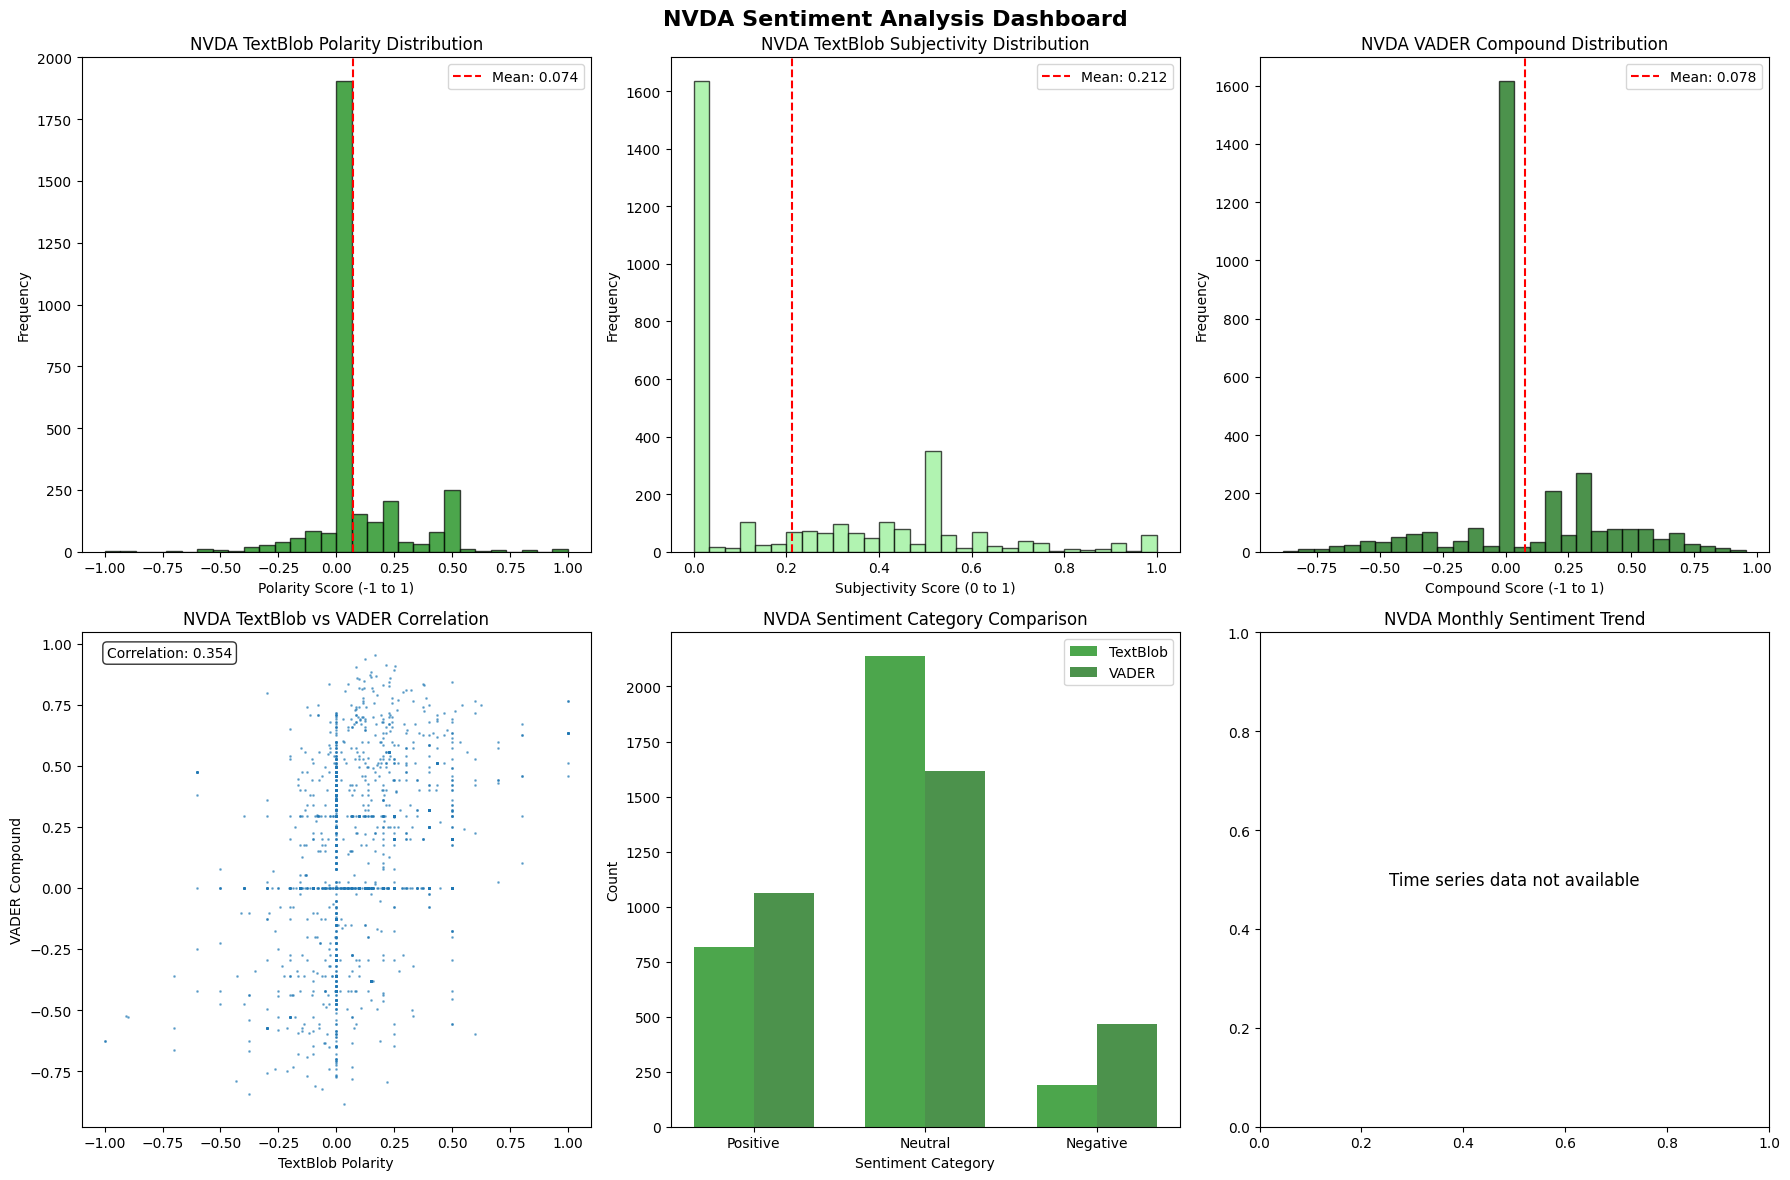

In [6]:
# Create NVDA sentiment visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('NVDA Sentiment Analysis Dashboard', fontsize=16, fontweight='bold')

# TextBlob Polarity distribution
axes[0, 0].hist(nvda_data['textblob_polarity'], bins=30, alpha=0.7, color='green', edgecolor='black')
axes[0, 0].set_title('NVDA TextBlob Polarity Distribution')
axes[0, 0].set_xlabel('Polarity Score (-1 to 1)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(nvda_data['textblob_polarity'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {nvda_data["textblob_polarity"].mean():.3f}')
axes[0, 0].legend()

# TextBlob Subjectivity distribution
axes[0, 1].hist(nvda_data['textblob_subjectivity'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('NVDA TextBlob Subjectivity Distribution')
axes[0, 1].set_xlabel('Subjectivity Score (0 to 1)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(nvda_data['textblob_subjectivity'].mean(), color='red', linestyle='--',
                   label=f'Mean: {nvda_data["textblob_subjectivity"].mean():.3f}')
axes[0, 1].legend()

# VADER Compound distribution
axes[0, 2].hist(nvda_data['vader_compound'], bins=30, alpha=0.7, color='darkgreen', edgecolor='black')
axes[0, 2].set_title('NVDA VADER Compound Distribution')
axes[0, 2].set_xlabel('Compound Score (-1 to 1)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].axvline(nvda_data['vader_compound'].mean(), color='red', linestyle='--',
                   label=f'Mean: {nvda_data["vader_compound"].mean():.3f}')
axes[0, 2].legend()

# Correlation scatter plot
axes[1, 0].scatter(nvda_data['textblob_polarity'], nvda_data['vader_compound'], alpha=0.5, s=1)
axes[1, 0].set_title('NVDA TextBlob vs VADER Correlation')
axes[1, 0].set_xlabel('TextBlob Polarity')
axes[1, 0].set_ylabel('VADER Compound')
axes[1, 0].text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform=axes[1, 0].transAxes,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Sentiment categories
def categorize_sentiment(score, tool='textblob'):
    if tool == 'textblob':
        if score > 0.1:
            return 'Positive'
        elif score < -0.1:
            return 'Negative'
        else:
            return 'Neutral'
    else:  # VADER
        if score >= 0.05:
            return 'Positive'
        elif score <= -0.05:
            return 'Negative'
        else:
            return 'Neutral'

nvda_data['textblob_category'] = nvda_data['textblob_polarity'].apply(lambda x: categorize_sentiment(x, 'textblob'))
nvda_data['vader_category'] = nvda_data['vader_compound'].apply(lambda x: categorize_sentiment(x, 'vader'))

# Category comparison
categories = ['Positive', 'Neutral', 'Negative']
tb_counts = [nvda_data['textblob_category'].value_counts().get(cat, 0) for cat in categories]
vader_counts = [nvda_data['vader_category'].value_counts().get(cat, 0) for cat in categories]

x = np.arange(len(categories))
width = 0.35

axes[1, 1].bar(x - width/2, tb_counts, width, label='TextBlob', color='green', alpha=0.7)
axes[1, 1].bar(x + width/2, vader_counts, width, label='VADER', color='darkgreen', alpha=0.7)
axes[1, 1].set_title('NVDA Sentiment Category Comparison')
axes[1, 1].set_xlabel('Sentiment Category')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(categories)
axes[1, 1].legend()

# Time series of sentiment (if dates are available)
try:
    nvda_data['date_clean'] = pd.to_datetime(nvda_data['date'], errors='coerce')
    nvda_time = nvda_data.dropna(subset=['date_clean']).copy()
    nvda_time = nvda_time.sort_values('date_clean')
    
    # Resample by month for smoother trend
    nvda_time.set_index('date_clean', inplace=True)
    monthly_sentiment = nvda_time['textblob_polarity'].resample('M').mean()
    
    axes[1, 2].plot(monthly_sentiment.index, monthly_sentiment.values, marker='o', linewidth=2, color='green')
    axes[1, 2].set_title('NVDA Monthly Sentiment Trend')
    axes[1, 2].set_xlabel('Date')
    axes[1, 2].set_ylabel('Average Polarity')
    axes[1, 2].tick_params(axis='x', rotation=45)
    axes[1, 2].grid(True, alpha=0.3)
except:
    axes[1, 2].text(0.5, 0.5, 'Time series data not available', ha='center', va='center',
                   transform=axes[1, 2].transAxes, fontsize=12)
    axes[1, 2].set_title('NVDA Monthly Sentiment Trend')

plt.tight_layout()
plt.show()

In [7]:
# Show extreme sentiment examples for NVDA
print("=== NVDA EXTREME SENTIMENT EXAMPLES ===")

# Most positive headlines (TextBlob)
most_positive_tb = nvda_data.nlargest(5, 'textblob_polarity')[['headline', 'textblob_polarity', 'vader_compound']]
print("\nMost Positive NVDA Headlines (TextBlob):")
for idx, row in most_positive_tb.iterrows():
    print(f"   {row['textblob_polarity']:.3f}: {row['headline'][:80]}...")

# Most negative headlines (TextBlob)
most_negative_tb = nvda_data.nsmallest(5, 'textblob_polarity')[['headline', 'textblob_polarity', 'vader_compound']]
print("\nMost Negative NVDA Headlines (TextBlob):")
for idx, row in most_negative_tb.iterrows():
    print(f"   {row['textblob_polarity']:.3f}: {row['headline'][:80]}...")

# Most positive headlines (VADER)
most_positive_vader = nvda_data.nlargest(5, 'vader_compound')[['headline', 'vader_compound', 'textblob_polarity']]
print("\nMost Positive NVDA Headlines (VADER):")
for idx, row in most_positive_vader.iterrows():
    print(f"   {row['vader_compound']:.3f}: {row['headline'][:80]}...")

# Most negative headlines (VADER)
most_negative_vader = nvda_data.nsmallest(5, 'vader_compound')[['headline', 'vader_compound', 'textblob_polarity']]
print("\nMost Negative NVDA Headlines (VADER):")
for idx, row in most_negative_vader.iterrows():
    print(f"   {row['vader_compound']:.3f}: {row['headline'][:80]}...")

=== NVDA EXTREME SENTIMENT EXAMPLES ===

Most Positive NVDA Headlines (TextBlob):
   1.000: 5 Best ETFs Of 2019...
   1.000: Decoding AMD's Breathtaking 2-Year Rally...
   1.000: Shoppers Rise To The Occasion As Walmart Reports Another Impressive Quarter...
   1.000: This Leveraged ETF Rapidly Became One Of November's Best...
   1.000: Bitcoin, China, And AI Highlight Some Of The Year's Best ETFs...

Most Negative NVDA Headlines (TextBlob):
   -1.000: Traders See Signs Of Rotation Into Financials Amid Nasdaq's Worst Day In Months...
   -1.000: Worst Performing Industries For November 14, 2016...
   -0.910: 'Dr Doom': Even If The Dow Goes To 100,000, It Will 'End Very Badly' For Investo...
   -0.900: Chowdhry: Betting Against Nvidia Is 'Insane' And Stupid...
   -0.700: Citron Turns Bullish On Nvidia, But Technicals Still Look Ugly...

Most Positive NVDA Headlines (VADER):
   0.955: Shares of several technology companies are trading higher as markets gain on pos...
   0.936: Shares of se

In [8]:
# Save NVDA results
print("=== SAVING NVDA RESULTS ===")

# Create output dataframe
nvda_output = nvda_data[['headline', 'publisher', 'date', 'stock', 
                       'textblob_polarity', 'textblob_subjectivity', 'textblob_category',
                       'vader_compound', 'vader_positive', 'vader_negative', 'vader_category']].copy()

# Save to CSV
output_file = '../../../data/sentiment_analysis_NVDA.csv'
nvda_output.to_csv(output_file, index=False)
print(f"NVDA results saved to: {output_file}")
print(f"Total NVDA headlines processed: {len(nvda_output)}")

# Display final summary
print("\n=== NVDA FINAL SUMMARY ===")
print(f"Dataset: {len(nvda_data):,} NVDA headlines")
print(f"Date range: {pd.to_datetime(nvda_data['date'], errors='coerce').min()} to {pd.to_datetime(nvda_data['date'], errors='coerce').max()}")
print(f"Unique publishers: {nvda_data['publisher'].nunique()}")
print(f"TextBlob - Mean polarity: {nvda_data['textblob_polarity'].mean():.4f}")
print(f"VADER - Mean compound: {nvda_data['vader_compound'].mean():.4f}")

agreement = (nvda_data['textblob_category'] == nvda_data['vader_category']).mean()
print(f"Tool agreement: {agreement:.2%}")

print("\n=== NVDA SENTIMENT CATEGORY DISTRIBUTIONS ===")
print("\nTextBlob Categories:")
print(nvda_data['textblob_category'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\nVADER Categories:")
print(nvda_data['vader_category'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

=== SAVING NVDA RESULTS ===
NVDA results saved to: ../../../data/sentiment_analysis_NVDA.csv
Total NVDA headlines processed: 3146

=== NVDA FINAL SUMMARY ===
Dataset: 3,146 NVDA headlines
Date range: 2020-05-31 11:05:12-04:00 to 2020-06-10 12:37:10-04:00
Unique publishers: 152
TextBlob - Mean polarity: 0.0738
VADER - Mean compound: 0.0777
Tool agreement: 62.65%

=== NVDA SENTIMENT CATEGORY DISTRIBUTIONS ===

TextBlob Categories:
textblob_category
Neutral     67.99%
Positive    25.97%
Negative     6.04%
Name: proportion, dtype: str

VADER Categories:
vader_category
Neutral     51.37%
Positive    33.82%
Negative    14.81%
Name: proportion, dtype: str


## NVDA Sentiment Analysis Summary

### Key Findings:
- **Overall Sentiment**: [Based on mean polarity/compound scores]
- **Sentiment Distribution**: [Analysis of positive/negative/neutral breakdown]
- **Subjectivity Level**: [Analysis of how objective vs subjective NVDA news is]
- **Tool Agreement**: [How well TextBlob and VADER agree on NVDA sentiment]

### Insights:
- NVDA is a key AI and semiconductor company, sentiment reflects tech sector health
- High news volume indicates strong investor interest in AI trends
- Sentiment patterns may correlate with product launches, earnings, and AI developments

### Recommendations:
- Monitor NVDA sentiment as a proxy for AI sector sentiment
- Use sentiment trends to anticipate market movements in tech sector
- Compare NVDA sentiment with broader semiconductor stocks for relative analysis